# Create agent with langchain and without it 

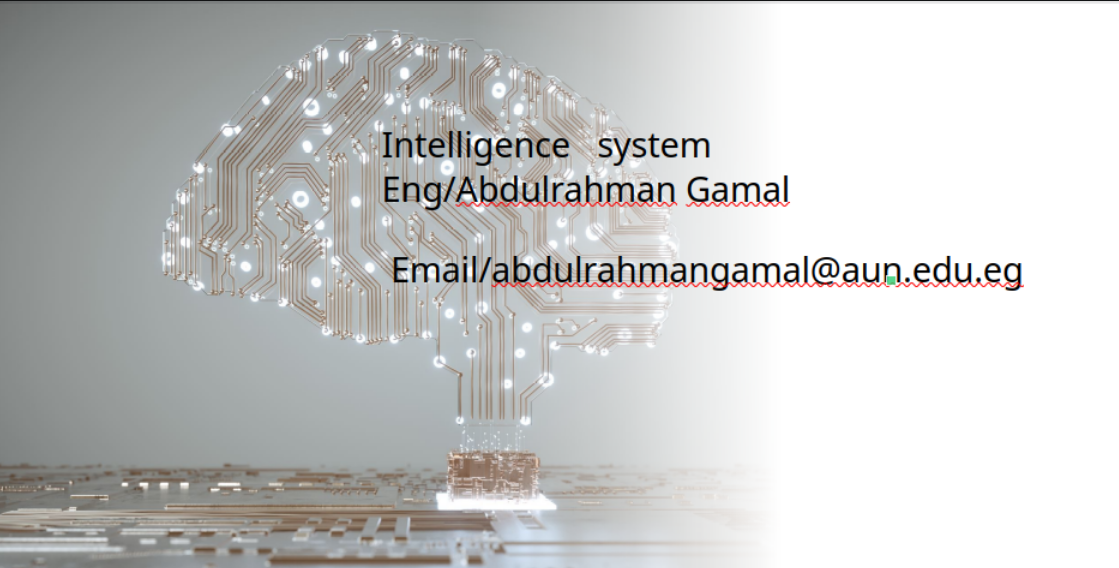

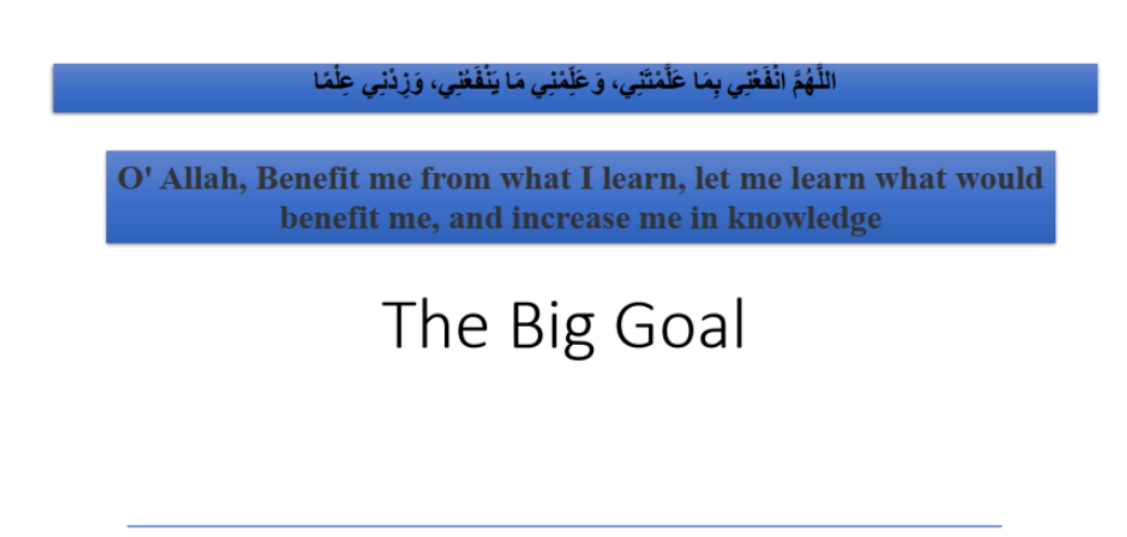

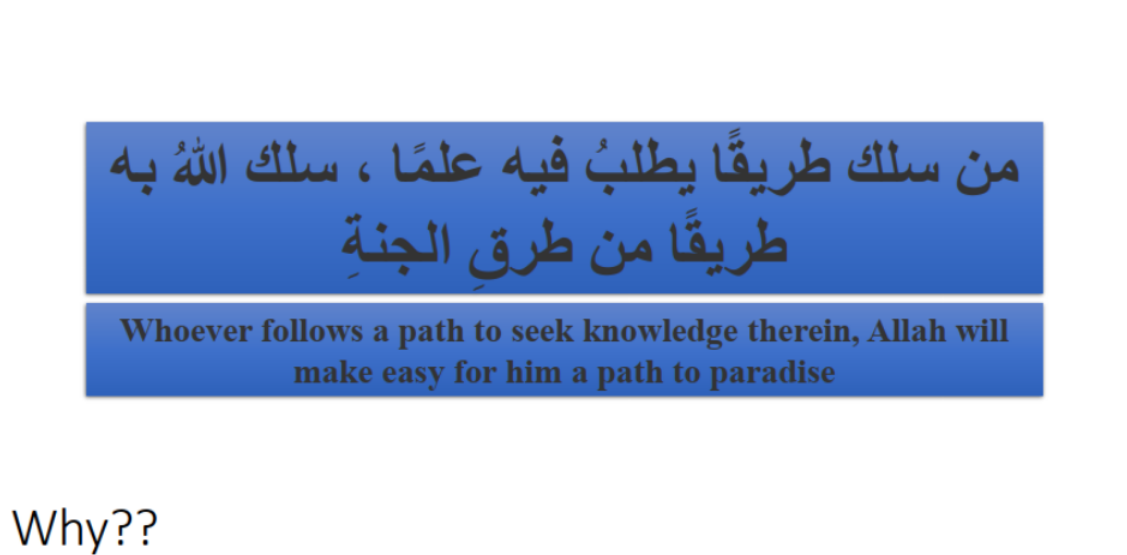

# What is  Agent ?


An agent is a software system that uses Llms as a reasoning engine to decide what actions to take,and then execute those actions.

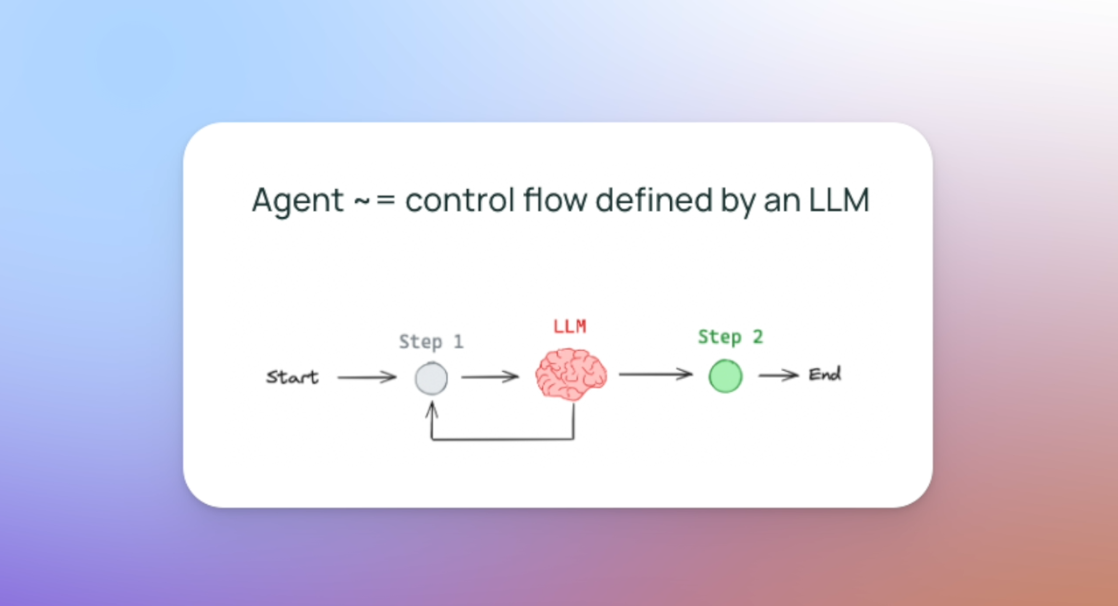


So unlike simple chains in renewables, where the sequence of actions are hard coded agents dynamically
determined which tools or steps need to be taken to solve a specific task, or to answer specific questions.

`The important thing to note here is that the LLM in an agent is deciding what to do next.`


`in chain We might use an LLM, maybe to summarize something or to generate some text.`
` However, we as developers, we define the entire control flow.We defined what is going to happen next.`



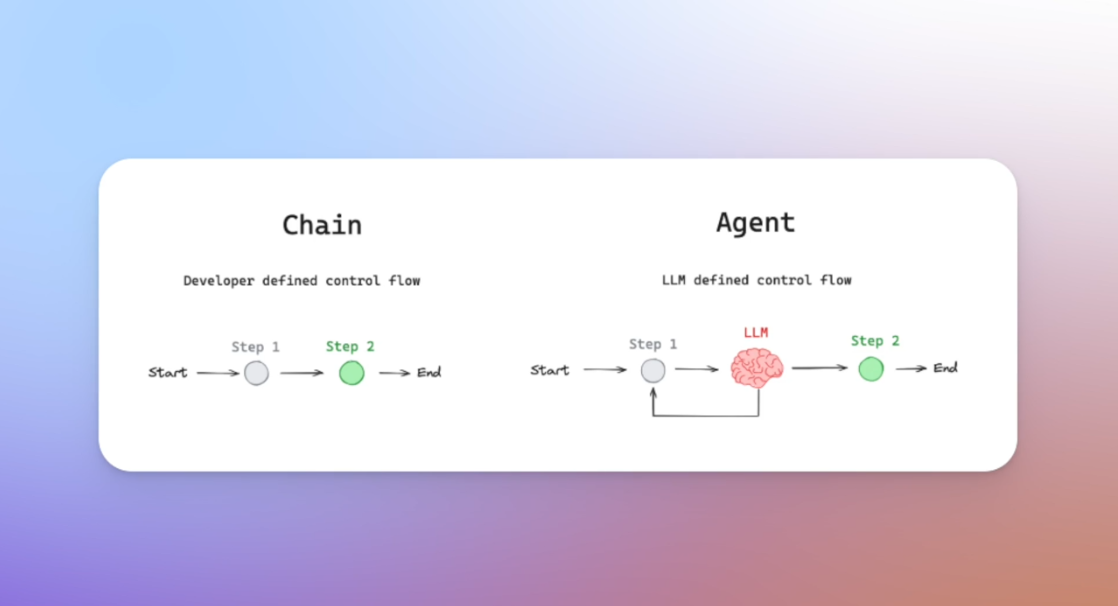


So this is the main difference between an agent and a regular chain.


## Core manifestation of agents

Now the core manifestation of agents in the real world is the example of taking an LLM and equipping
it with `tools `so we can give it, maybe a tool to make `an API call,` to do a `search`, to read from a
database, or to `simply write` and `execute some code`.


And this means that we can basically give our `llms superpowers `to `do anything`, because we can connect
them to do anything with agents.



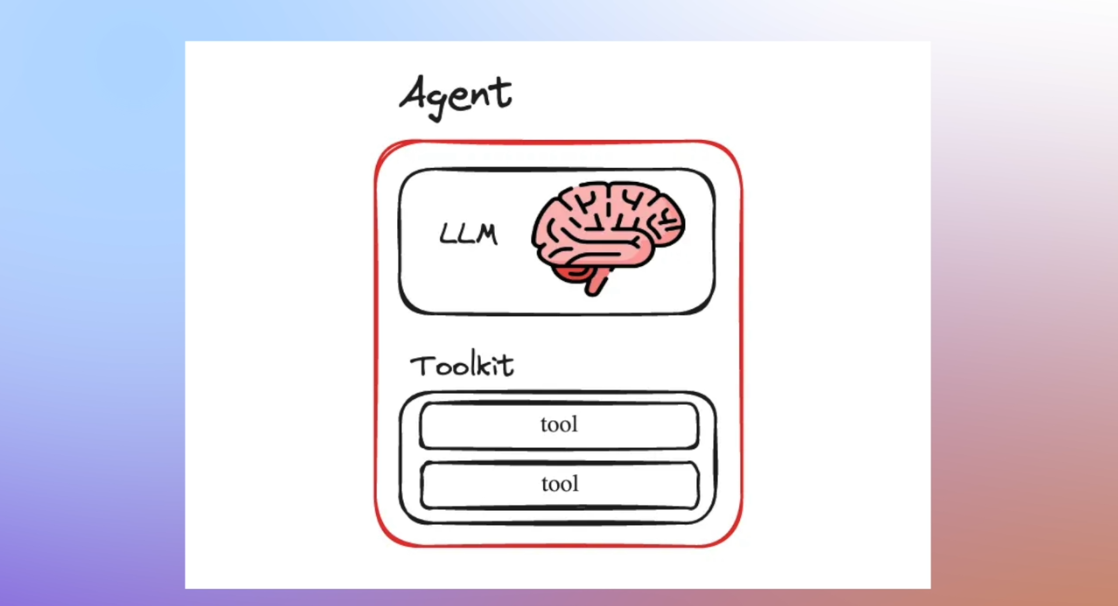


## ReAct agent 

it's a specific type of an agent architecture that follows the react paradigm.
Now the name ` react comes from reasoning in acting`.
And this was a paper, um, that was published and was really the stepping stone of implementing agents.

And in this approach, we combine the reasoning power of llms to think through the problem with chain
of thought prompting, 


Then we have the freedom to to really write anything we want, and we can equip our LM with any capability
that we want to.

Now this is going to happen in an iterative loop until the task is complete.
And `lank chain `and lank graph `provides `us with pre-built `react agents `that we can create and customize


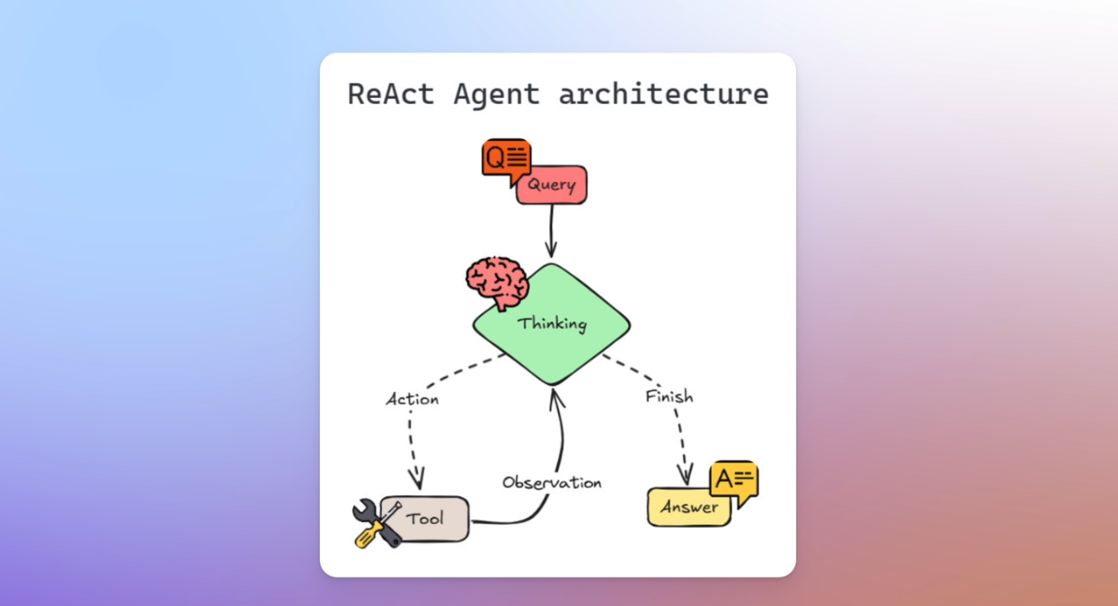



## Example on agent  : 

chatgpt with search tool 

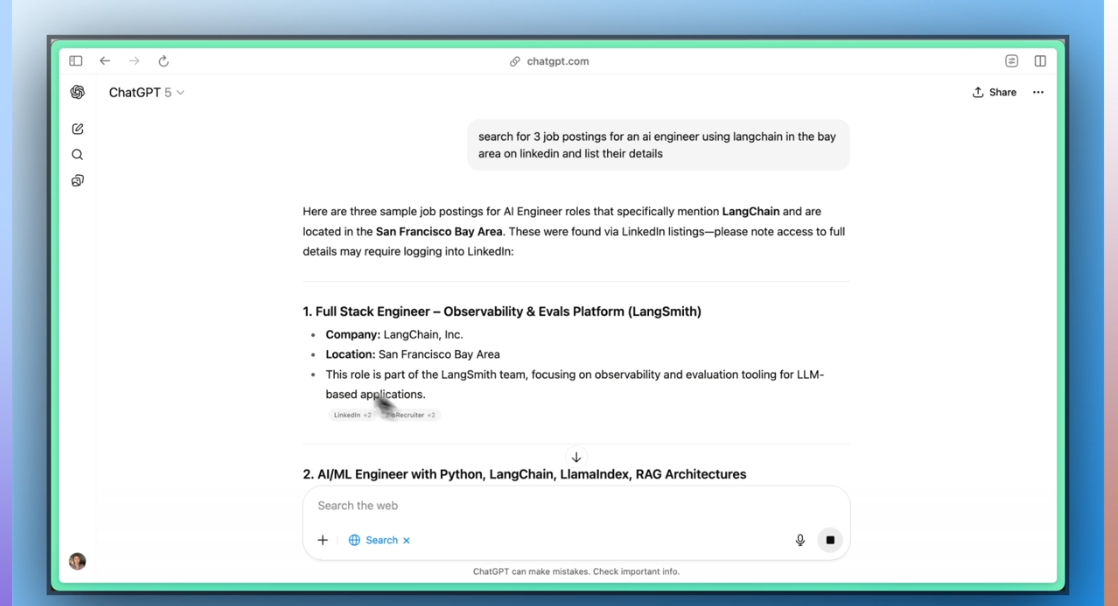

## implement search agent    

in the past ,chat applications, they didn't have built in search.   
And today all of those chat applications have built in search, and it's very useful and it's quite a standard right now.

However, back in the day, this was not the case.`And it's interesting to see how those chat applications evolved.`   


`So in this section` we'll be implementing with Langchain a search engine which is an LLM that's going
to have access to the exact same kind of search that we're seeing above.





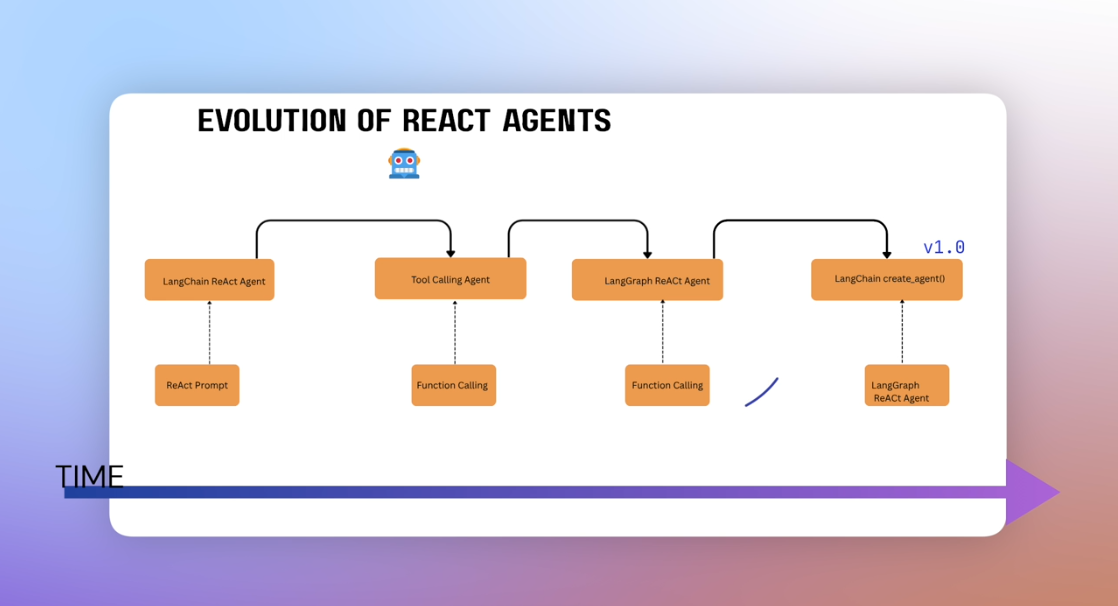

1-The react agent pattern has undergone significant evolution since it was introduced in LinkedIn back

in November of 2022, and initially, the Lang chain react agent relied purely on `react prompting`,
where the model would reason about the `actions and observations in a text based format`.    

2-And as the LM landscape evolved with the native `function calling` feature capabilities of large language
models, this architecture `transitioned into tool calling agents`, which leveraged the structured function
calling instead of prompt based tool selection.
And this made tool execution more reliable and more efficient.    


3-Now the next major leap came with the react agent, which` maintained function calling but rebuilt the`
`agent on top of the graph's` low level orchestration framework, providing with durable execution, persistence
ability and fine grained control needed for production grade applications.     


4-in the long chain version 1.0 linked Chain introduced the `create agent function`,
which provides a clean, `high level interface` while being powered with the battle tested Landgraph React




# In this section,
we'll walk through each one of these agent iterations.

Starting from the `latest and greatest create agent function`.
Moving back to the original OG react implementation in progressively build up towards the modern V1


`So you can understand not just how to use these agents, but how they actually work underneath the hood,`
what each iteration improved and it will give you a very strong intuition when implementing production

And the only thing you need to remember from this slide  is that we're going to be iterating through
agent implementations until we get to a final agent implementation, which is robust and production


## 1-setup  Env for langchain search agent 

So now we want to add a new package which is called langChain Tivoli.        
 
link: https://app.tavily.com/home

And `Tivoli is a third party which is going to help us connect our agent to the web and give the agent`
`searching capabilities so it will act as a search engine for our agent.`

And it also has other very useful APIs like Tivoli Crawl, Tivoli Map, Tivoli Extract, which are very

And by the way, today is actually the most popular choice for integrating a web search into an agent.
And they're even featured in the official documentation as the default service for a search engine 

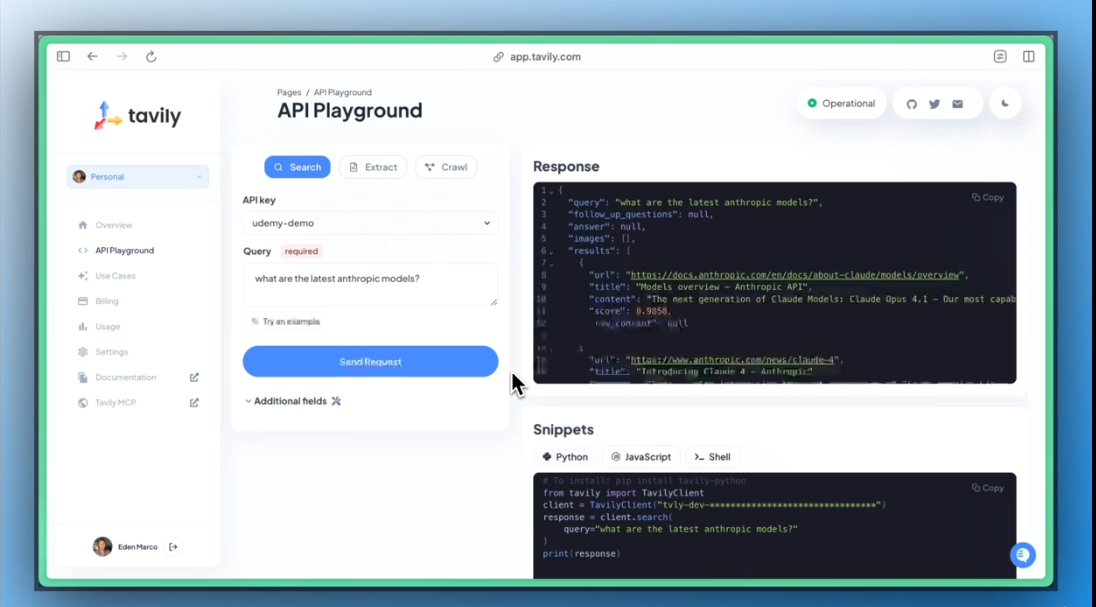


In [ ]:
! uv pip install langchain-tavily

Using Python 3.11.15 environment at: /home/abdulrahmangamal/miniconda3/envs/my_jupyter_env
Checked 1 package in 44ms


## Create tavily api key 

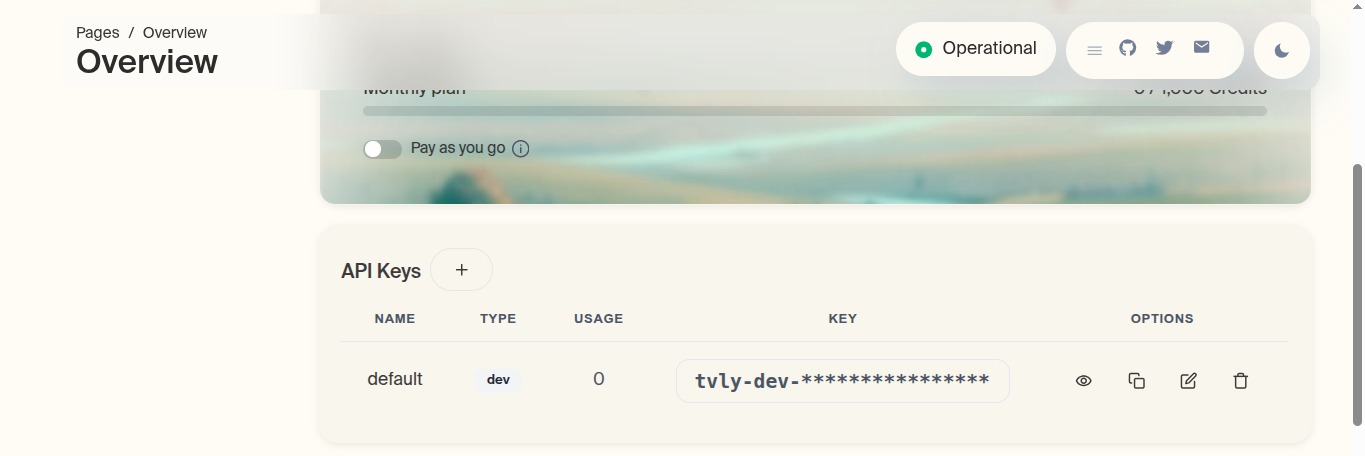

## Add to env var

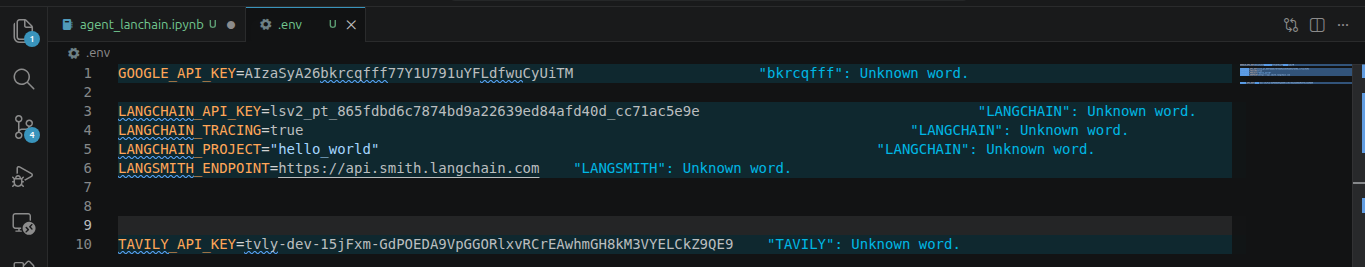

## Create first  agent  

Now, in order to create an agent, we need to give the agent `two minimal things`.

The `first `one is going to be` tools`, and the `second ` is going to be an `LM`, which is going to be the

 a `tool `is a `function `that an agent can execute.         
`It can be any function that we want.`   So we can write the internal implementation of that function.          

So this means we can give our agent endless possibilities of actions it can perform.
So we can make it call an API to search in a database to run and execute code.

And once we write this tool, we can plug it into the agent and boom!
Like magic, the agent has the ability to go and execute this tool.


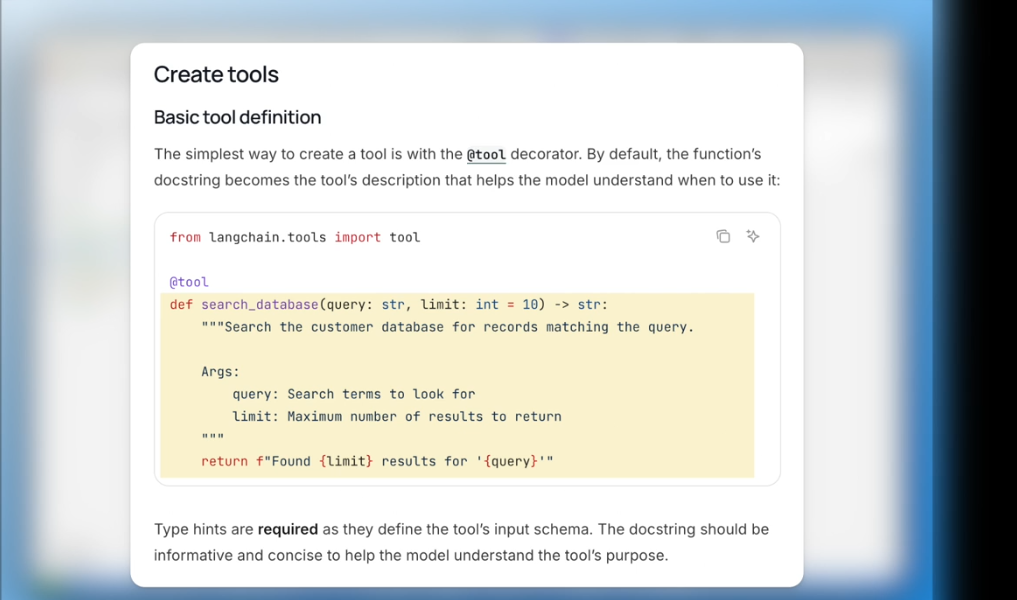

And `creating a tool `is actually very, very simple.
All we need to do is to `implement a function`, a regular Python function with type hints and with some
docstrings.


we'll have some `description` of what this function does, what `arguments does it receive `and 
what`output does it output.`

We then use the `tool decorator `by lank chain.
This `transforms `this regular Python function into a `tool` which can be plugged in into an agent.

Now the type hinting the arguments, names and the docstrings of the function are very, very important
But underneath the hood, the large language model is going to use this description and the arguments
type hints.

And it's going to be using that in order to choose whether to call this tool or not, and with which arguments    

and state of the art models these days support this functionality using something which is
called function calling, which we will be elaborating a lot on this course.

Now, the gist of function calling is that instead of LMS just returning text or pictures or videos,
they can also return a special response, which is a function that needs to be invoked in case it decides
And this is an extra capability that an LM can provide us.

And we are going to be treating this like a black box right now.




In [11]:
# import section 

from dotenv import load_dotenv
load_dotenv()

from langchain.agents import create_agent
from langchain.tools import tool
from langchain_core.messages import HumanMessage



In [12]:
# implement search tool 
from langchain.tools import tool

@tool
def search(query: str) -> str:
    """
    Tool that searches over internet
    Args:
        query: The query to search for
    Returns:
        The search result
    """
    print(f"Searching for {query}")
    return "Tokyo weather is sunny"


# what is the benfit of @tool decorator?
#But what chain is going to do is going to take all this metadata of the tool, name the arguments that
#they take the description and it's going to format it nicely, and it's going to help us plug this metadata
#and this information to an LLM call.



In [13]:
# create agent 

from langchain_google_genai import ChatGoogleGenerativeAI
from  langchain_ollama import ChatOllama

#llm = ChatGoogleGenerativeAI(model="gemini-2.0-flash")
#llm = ChatOllama(model="gemma:2b")
llm= ChatOllama(model="qwen2.5:1.5b")
tools = [search]
agent = create_agent(model=llm, tools=tools)


#

In [14]:
# call agents

print("Hello from langchain-course!")
response = agent.invoke({"messages": [HumanMessage(content="What is the weather in Tokyo?")]})
print(response)

#some  model support tools/ function calling in the response
#ollama pull qwen2.5:0.5b
#ollama pull qwen2.5:1.5b
#ollama pull llama3.2:1b

Hello from langchain-course!


KeyboardInterrupt: 

## Trace code " From query to answer  "  

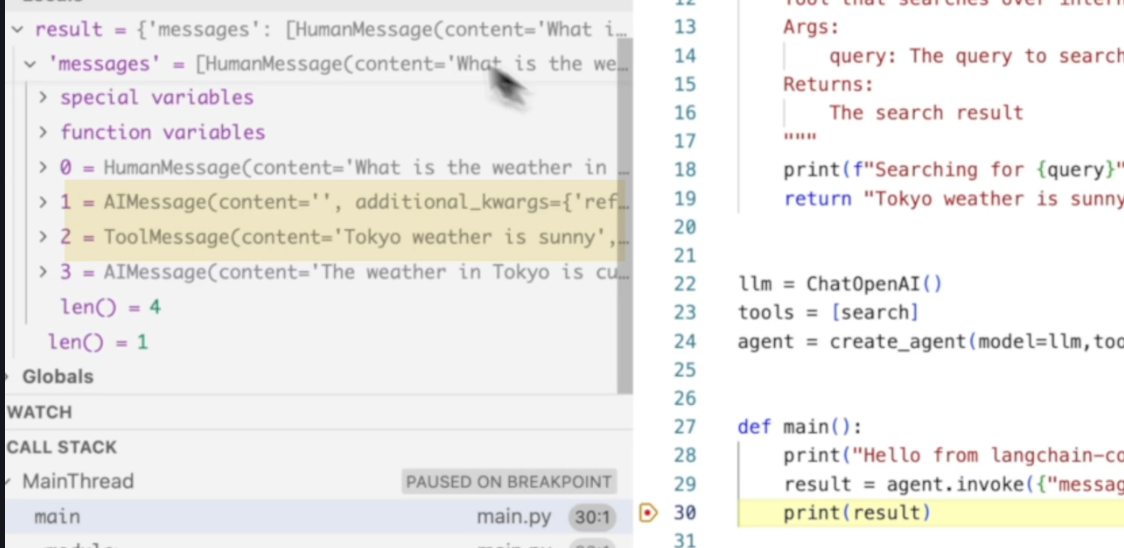

So you can see it's a human message with the content of what is the weather in Tokyo.

And the answer is in the last message, and we can see it's labeled as an AI message, where it says
that the weather in Tokyo is currently sunny.

`Now, what's in between?`

We have here an AI message and a tool message.

`And those are actually what is the agent is doing in order to get this answer.`
So right now it is sort of like magic.


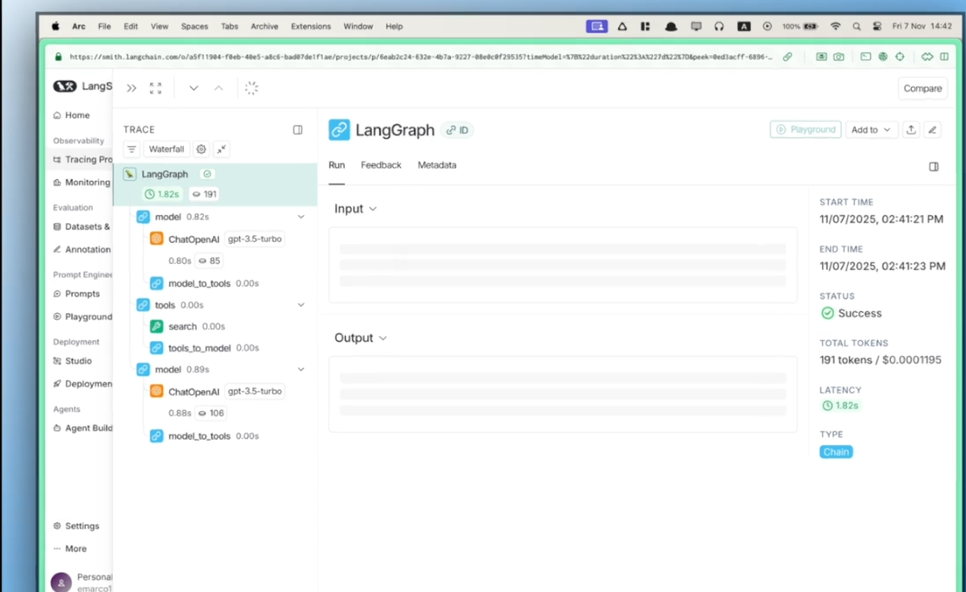


Now you can see now that the title here of this execution is called Land Graph.     

And this is because underneath the hood in the internals, it's going to be executing via the graph


what inside Model  call "input , output ,and tool"     

Note in the top  there exist all tool  provide to agent or model 

And with the query of what is the weather in Tokyo, it decided that it needs to invoke the search tool
with the query weather in Tokyo.

So notice here the LM response is ` not,The invocation of this tool ` is        
` simply which tool to call and with which arguments here`.
The invocation of this tool is simply which tool to call and with which arguments here.


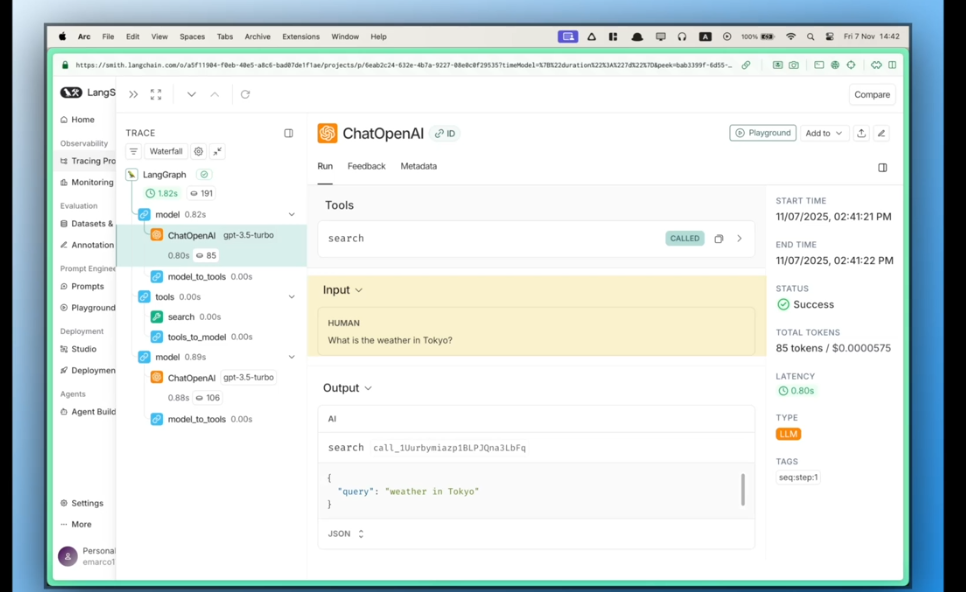

Alright, so after the LM decided that it needs to call the search tool `lank chain then went and invoked   ` 
`the search tool with the query Weather in Tokyo.`


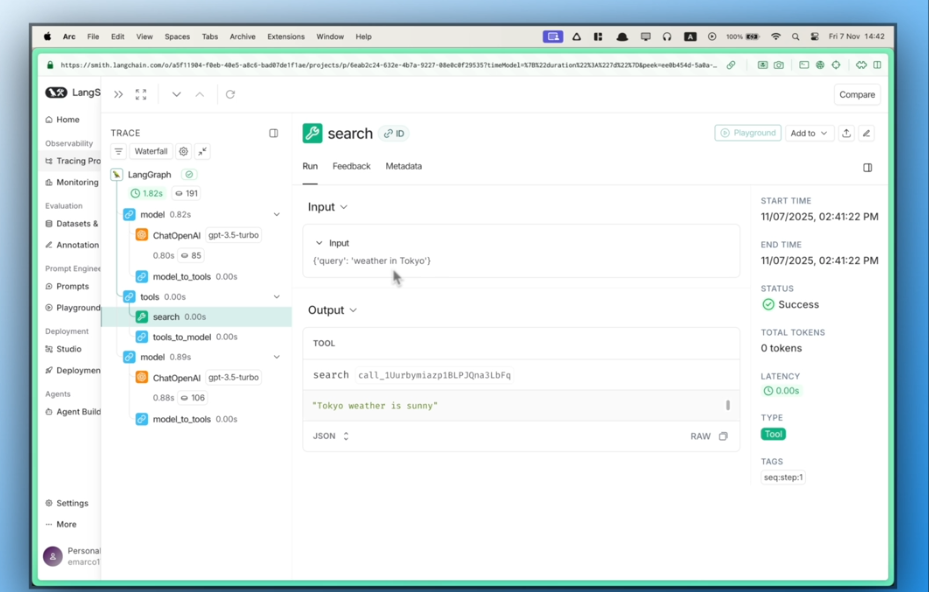

## Recap  

So the LM decided which tool to call with which arguments.
Then link chain went in ran this function with those arguments.

So we have here a reasoning engine that decides which tool to call and with which arguments.
And we have here now an agent execution runtime which actually goes in execute and run those tools and
get output

Now link chain is going to be making another LM call, but this time it's going to contain the input.

It's going to contain the `LM decision to call the search tool`, and it's going to contain the answer `after executing the search tool.`

So the LLM should have a very easy time now generating the answer, because it has all the information
And we can see here that the answer is that the weather in Tokyo is currently sunny right now.



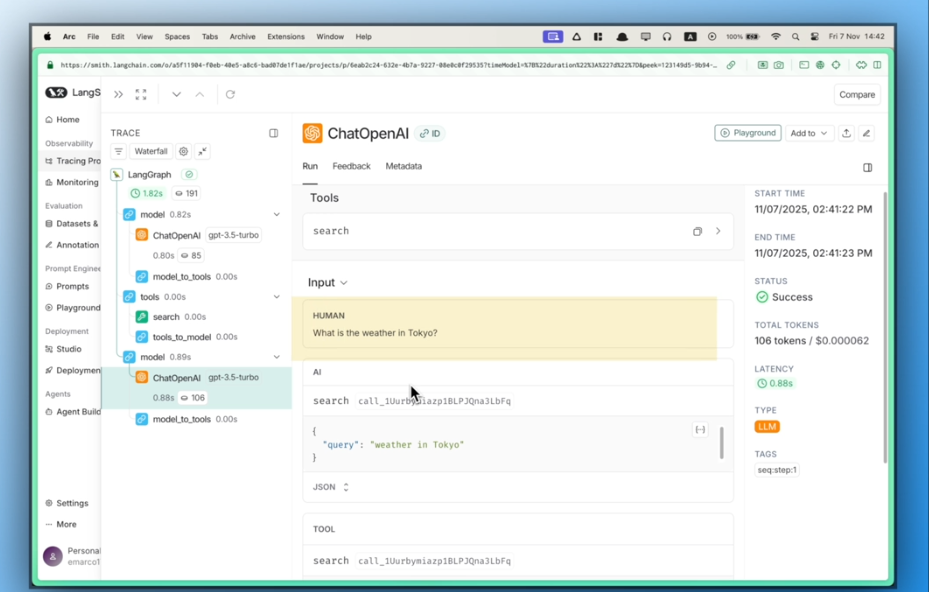

Remember that I told you that now all of those messages are going to be making more sense.

- The first message was the input.


- The second message was the AI's decision to call the search tool, and with which arguments link chain

- langchain  went and executed that tool.
    And then the result of this tool is structured here in this `tool message object`.

    And the tool message is simply a data structure to represent a result of a tool execution.     
    And in this case the result of executing the search tool.

- And finally link chain went and made another LLM call with the input with the decision of the LLM to
execute the search tool and with the search tool a result.

And then the final answer is that the weather in Tokyo is sunny.




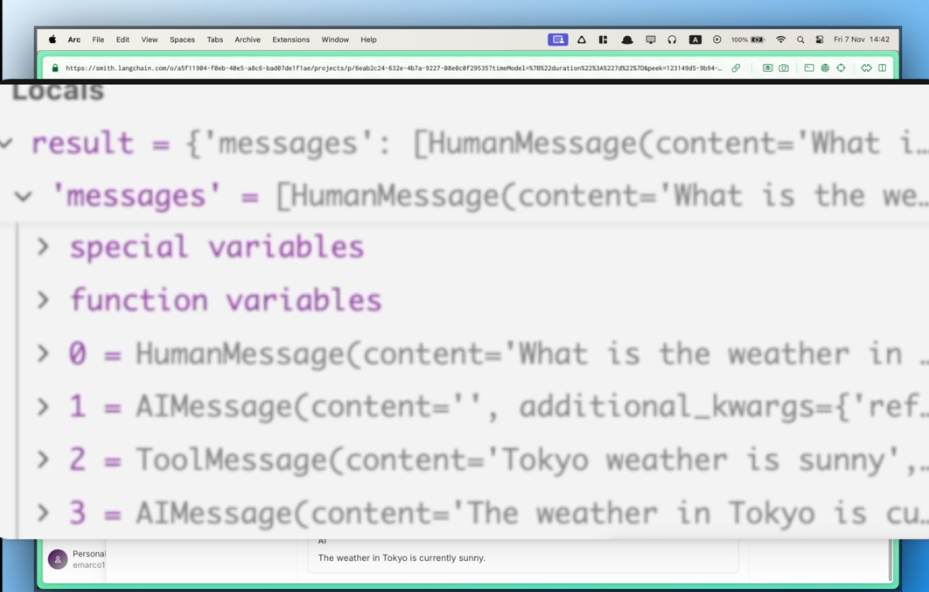

And also notice that the final LM call did not choose to execute a tool, but it chose to return an
answer because it had all the information it needed.


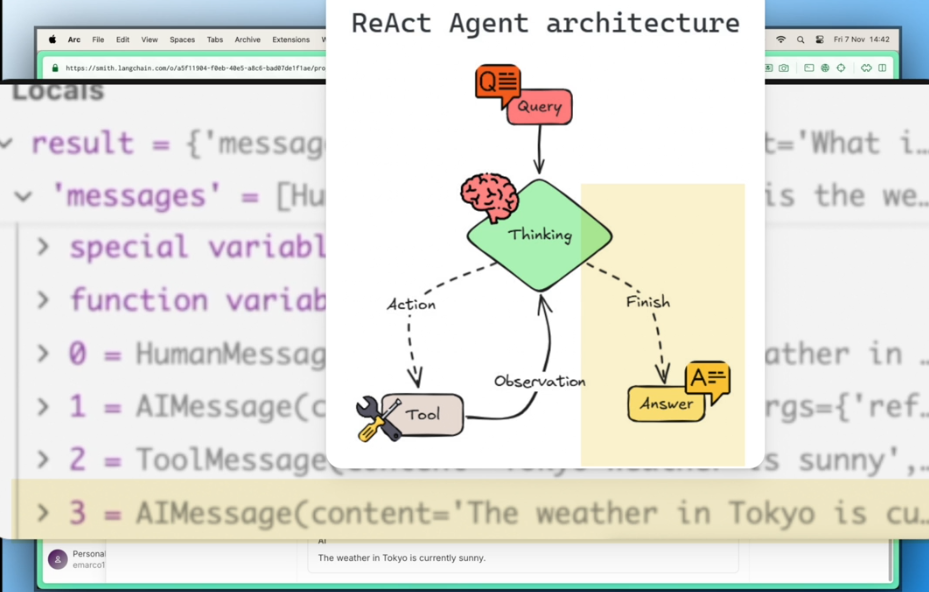

## Integrating Real-World Search with Tavily and LangChain Tools

In [6]:
#And I'm going to initialize the client from tavily


from dotenv import load_dotenv
load_dotenv()
 
from tavily import TavilyClient

tavily=TavilyClient()

#And this client when it's going to initialize and it's going to be looking for an environment variable
#So this is where we put in our dot env file the API key.


In [9]:
#So let me now instead of returning the Tokyo weather is sunny, let's go and run the actual search query
#We'll be doing it with Tavileh.

from langchain.tools import tool


@tool
def search(query: str) -> str:
    """
    Tool that searches over internet
    Args:
        query: The query to search for
    Returns:
        The search result
    """
    print(f"Searching for {query}")
    return tavily.search(query=query)



from langchain.agents import create_agent
from langchain_core.messages import HumanMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from  langchain_ollama import ChatOllama

#llm = ChatGoogleGenerativeAI(model="gemini-2.0-flash")
llm = ChatOllama(model="qwen2.5:1.5b")
tools = [search]
agent = create_agent(model=llm, tools=tools)

In [ ]:
# call agents

print("Hello from langchain-course!")
response = agent.invoke({"messages": [HumanMessage(content="What is the weather in Tokyo?")]})
print(response)


## And this is an example of a search made. 

And here you can see all the information of the weather.     
So it also provided us with other results and other answers.              
So it provided us with the top results here.           
And if we want we can control this parameter of how many results you get.        
 

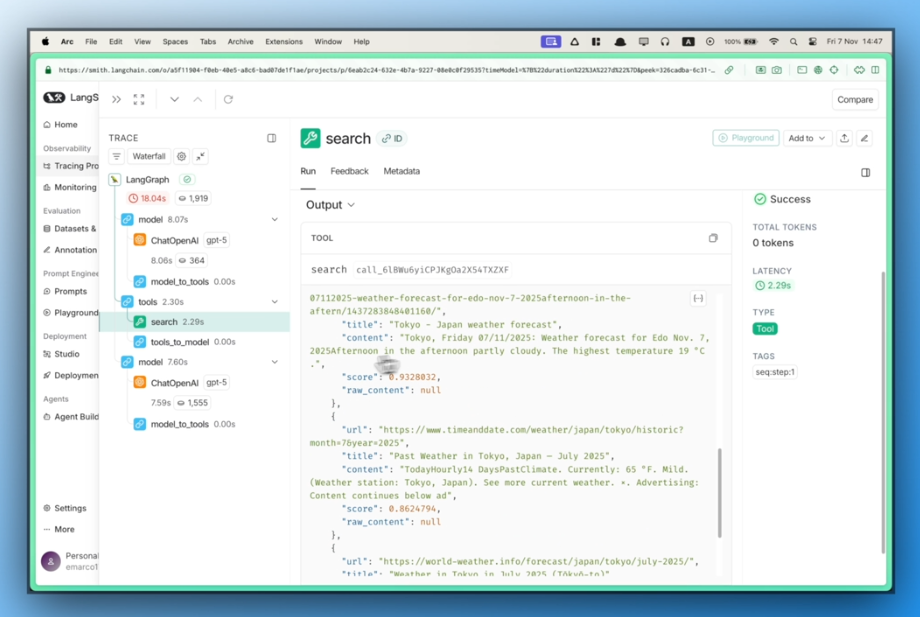

And if I go to the last LM response here, we can see now we get a different answer, which is a much  

more elaborate answer here, which is grounded on real time information, which we got through research.
 


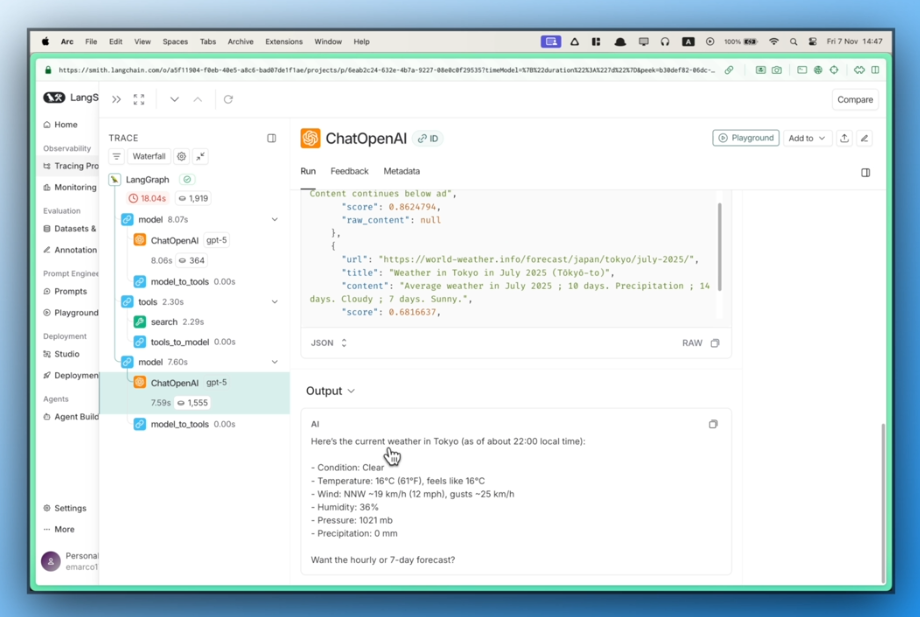

## change the query 

`search for 3 job postings for an ai engineer using langchain in the bay area on linkedin and list their details`   



In [1]:

from dotenv import load_dotenv
load_dotenv()
 
from tavily import TavilyClient

tavily=TavilyClient()

from langchain.tools import tool

@tool
def search(query: str) -> str:
    """
    Tool that searches over internet
    Args:
        query: The query to search for
    Returns:
        The search result
    """
    print(f"Searching for {query}")
    return tavily.search(query=query)



from langchain.agents import create_agent
from langchain_core.messages import HumanMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from  langchain_ollama import ChatOllama

#llm = ChatGoogleGenerativeAI(model="gemini-2.0-flash")
llm = ChatOllama(model="qwen2.5:1.5b")
tools = [search]
agent = create_agent(model=llm, tools=tools)




In [ ]:

print("Hello from langchain-course!")
response = agent.invoke({"messages": [HumanMessage(content="search for 3 job postings for an ai engineer using langchain in the bay area on linkedin and list their details")]})
print(response)

Hello from langchain-course!


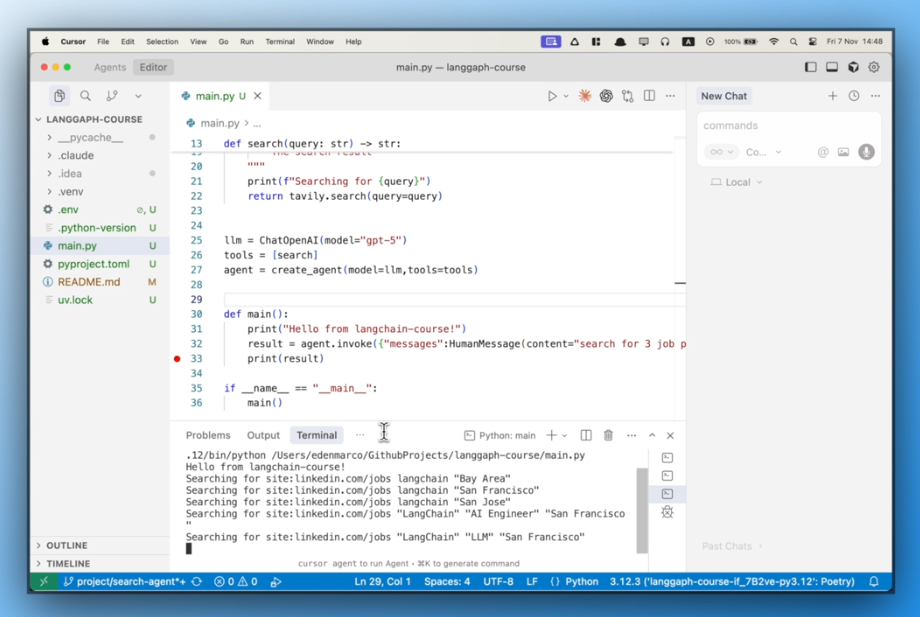


And notice that in the output of the LLM in the AI response here we get multiple tool calls.    
So the AI decides to call multiple tool calls.   
And it's going to execute them in parallel.   


And the final request to the MLM contains all the tool calls and all their answers.


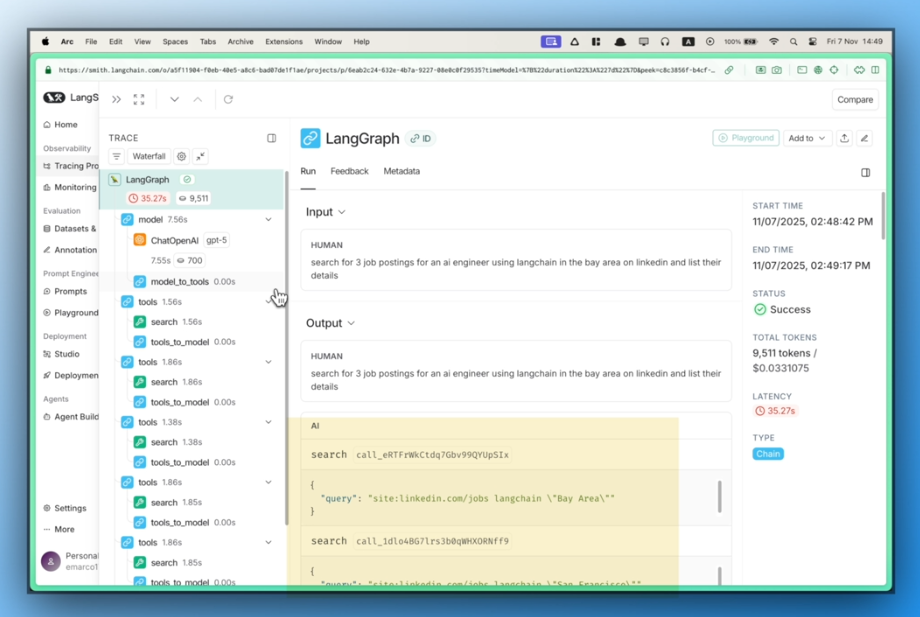

And let's see the final answer of the LM.
So and we got here all of the job postings on LinkedIn and the URL to LinkedIn.

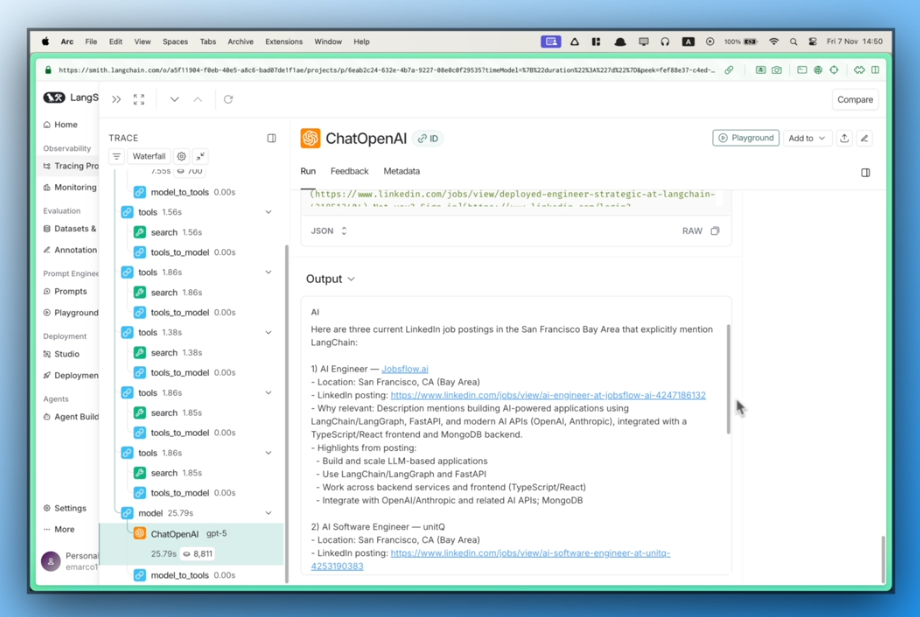

## best practice    
Remove the custom tool, and I'm going to use the built-in Tavileh search tool that the Tavileh team wrote.


in this case the team, to write a much better description,much better arguments, and they can do a far better job writing the link chain tools than we do here.


In [ ]:


from dotenv import load_dotenv
load_dotenv()
 
from langchain_tavily import TavilySearch


from langchain.tools import tool

from langchain.agents import create_agent
from langchain_core.messages import HumanMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from  langchain_ollama import ChatOllama


#llm = ChatGoogleGenerativeAI(model="gemini-2.0-flash")
llm = ChatOllama(model="qwen2.5:1.5b")

tools = [TavilySearch()]
agent = create_agent(model=llm, tools=tools)




In [ ]:

print("Hello from langchain-course!")
response = agent.invoke({"messages": [HumanMessage(content="search for 3 job postings for an ai engineer using langchain in the bay area on linkedin and list their details")]})
print(response)


Hello from langchain-course!


## Structured Output with LangChain Agents Using Pydantic

So most of the time when we're going to be building agents and AI applications, we are going to be
using llm and llms respond in text.

Now if we want to take this text and we want to create a structure to it, and we want to downstream   
it into an application, maybe to serialize it, maybe to render it in the user interface,...

So we don't just want text, we want maybe a JSON object or maybe a Pydantic object that we can go and 
we can downstream to our application and we can programmatically parse and work with.



And LinkedIn provides us a very easy way to do this with the create agent function.
We need to simply add an argument which is called response format.
And we're going to provide to this argument the schema that we want.
It may be a JSON schema.
It may be a Pydantic object.

And then magically the response that the agent is going to output us, is going to adhere to that scheme

So in this section, we're going to be creating a Pydantic object, and we're going to be creating a nested
Pydantic object just to add a bit of complexity to what we're building.

So the Pydantic object is going to be our agent response.

`consist of two thing  answer  and sources`
`answer is string ,sources is the list of url`


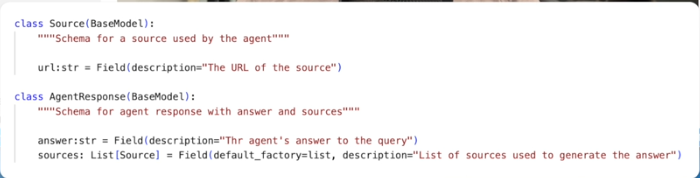


In [ ]:
from typing import List
from pydantic import BaseModel, Field
"""
Type enforces the strict data format (like text or numbers) to prevent code errors.
Description explains the context and meaning to guide the AI and prevent hallucinations.
"""

class Source(BaseModel):
    """Schema for a source used by the agent"""
    url: str = Field(description="The URL of the source")

class AgentResponse(BaseModel):
    """Schema for agent response with answer and sources"""
    answer: str = Field(description="Thr agent's answer to the query")
    sources: List[Source] = Field(default_factory=list, description="List of sources used to generate the answer")



In [ ]:


from dotenv import load_dotenv
load_dotenv()
 
from langchain_tavily import TavilySearch


from langchain.tools import tool

from langchain.agents import create_agent
from langchain_core.messages import HumanMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from  langchain_ollama import ChatOllama


#llm = ChatGoogleGenerativeAI(model="gemini-2.0-flash")
llm = ChatOllama(model="qwen2.5:1.5b")

tools = [TavilySearch()]

# only need to add response_format argument to create_agent function to create an agent with response schema validation
agent = create_agent(model=llm, tools=tools,response_format=AgentResponse)



In [ ]:
print("Hello from langchain-course!")
result = agent.invoke({"messages": [HumanMessage(content="search for 3 job postings for an ai engineer using langchain in the bay area on linkedin and list their details")]})
print(result)

And now in the result we have now a new key here which is called structured response here.
And the type of structured response is going to be agent response.

So it's going to have the answer field and it's going to have the sources field which is going to be
a list of sources.


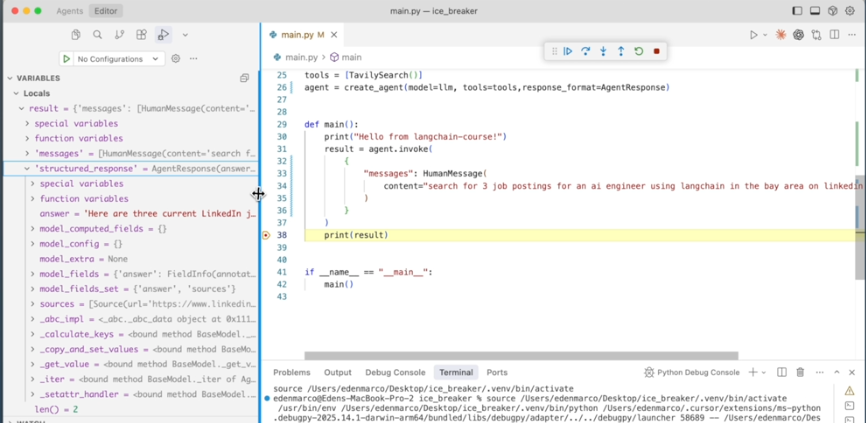

In [ ]:
print(result['structured_response'])
print(result['structured_response']['answer'])
print(result['structured_response']['sources'])

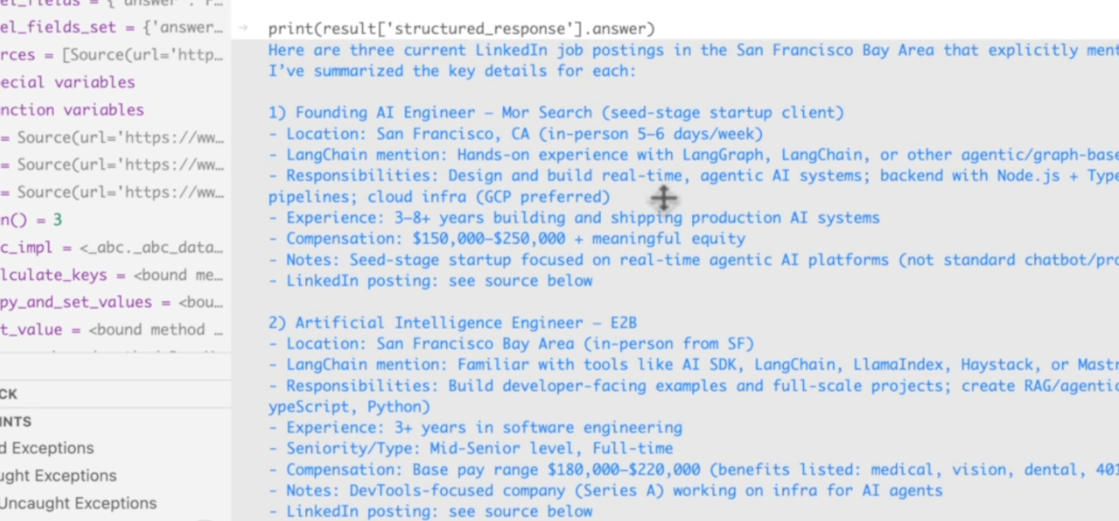

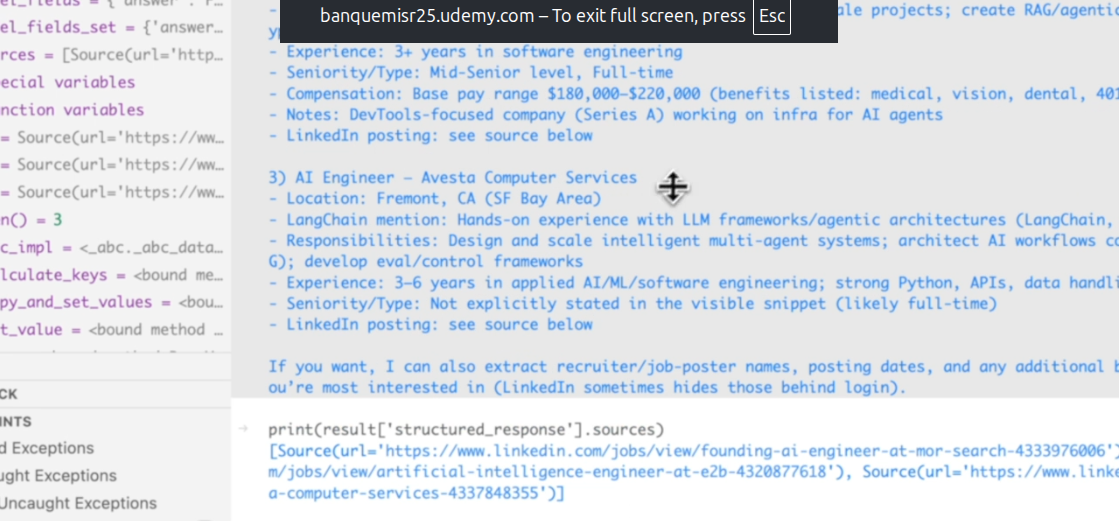

see new  attribute  contain the structure  output


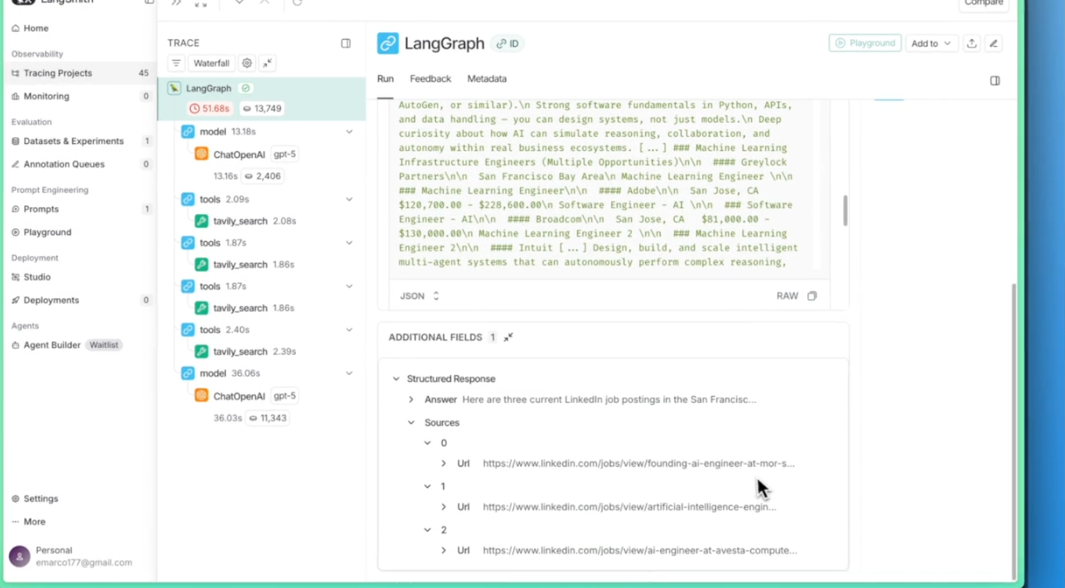

# Next section implement agent form scratch 

`this is my favorite section of the course.`


# Reference

1- LangChain- Develop AI Agents with LangChain & LangGraph       

https://banquemisr25.udemy.com/course/langchain/learn/lecture/52107223#overview

https://github.com/emarco177/langchain-course

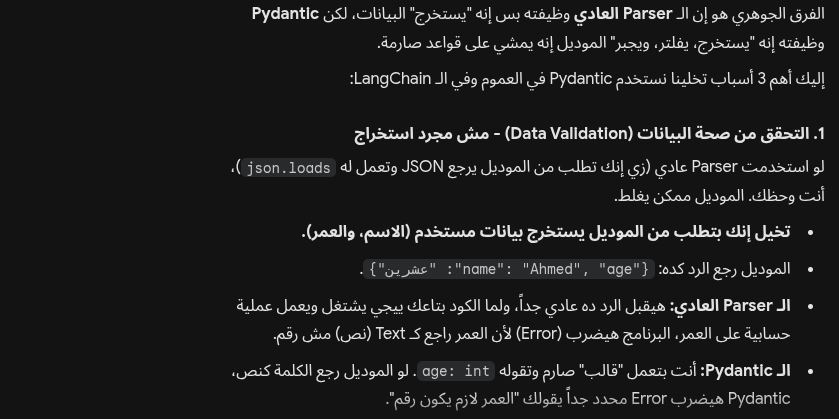
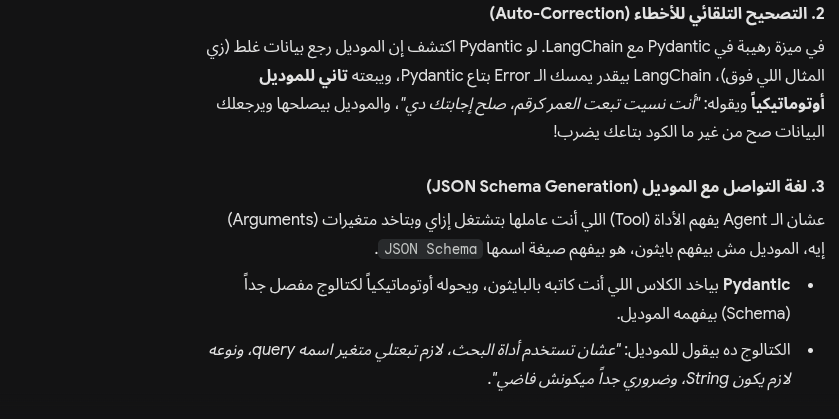